---
tags: [integration, optimization, variational]
---

# CUDA-Qサポート

このページでは、[QURI Partsサポートのページ](quri_parts_support.ipynb)と同じ具体的な最適化問題を通して、Qamomileの[CUDA-Q](https://nvidia.github.io/cuda-quantum/latest/)バックエンドを紹介します。
小さなMaxCutインスタンスを`BinaryModel.from_ising`でIsing問題として表し、QAOAアンザッツを`@qkernel`として直接書きます。
その量子カーネルを`CudaqTranspiler`/`CudaqExecutor`で実行する流れを見ていきましょう。
`CudaqExecutor`はactiveなCUDA-Q targetを使います。既定では、以下の例にはCUDA-QのローカルCPU simulatorだけで十分です。
その過程で、生成されたCUDA-Qソースを確認し、Qamomileの`STATIC` modeと`RUNNABLE` modeの違いも比較します。

In [1]:
# CUDA-Qのインストールtargetに合うオプション依存グループを指定して
# Qamomileをインストールします。
# !pip install "qamomile[cudaq-cu12]"  # CUDA 12.x, Linux
# !pip install "qamomile[cudaq-cu13]"  # CUDA 13.x, Linux or macOS ARM64

In [2]:
import os
from collections import Counter

import cudaq
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
from scipy.optimize import minimize

import qamomile.circuit as qmc
import qamomile.observable as qm_o
from qamomile.cudaq import CudaqExecutor, CudaqTranspiler, ExecutionMode
from qamomile.optimization.binary_model import BinaryModel

## MaxCut問題

CUDA-Q連携の説明に集中するため、[MaxCutに対するQAOAチュートリアル](../algorithm/qaoa_maxcut.ipynb)と同じ5ノードの小さなグラフを使います。
$\sum_{(i,j) \in E}(1 - s_i s_j)/2$を最大化することは、定数項を除けば、反強磁性Isingハミルトニアン$H_C = \sum_{(i,j) \in E} s_i s_j$を*最小化*することと同じです。
重みなしMaxCutではすべての$J_{ij} = 1$、$h_i = 0$なので、これらの係数をそのまま`BinaryModel.from_ising`に渡します。
ここで作るモデルは、QAOA量子カーネルに渡す`quad`/`linear`辞書と、測定結果をスピン値$(+1 / -1)$に戻すヘルパーを持つ問題コンテナとして使います。

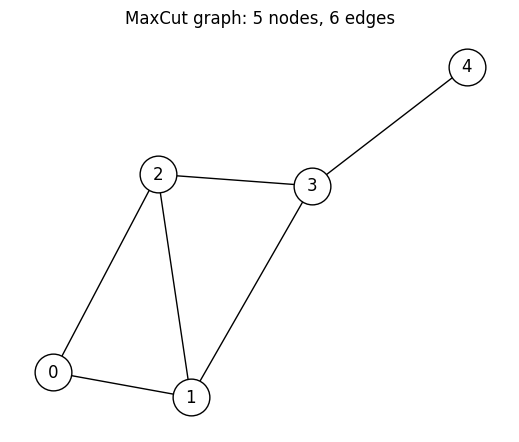

In [3]:
G = nx.Graph()
G.add_edges_from([(0, 1), (0, 2), (1, 2), (1, 3), (2, 3), (3, 4)])
num_nodes = G.number_of_nodes()

ising_quad: dict[tuple[int, int], float] = {
    tuple(sorted((i, j))): 1.0 for i, j in G.edges()
}
ising_linear: dict[int, float] = {}
spin_model = BinaryModel.from_ising(linear=ising_linear, quad=ising_quad)
# 問題構造はグラフから完全に決まります。重みなしMaxCutでは、quad項は辺と
# 1対1に対応し、linear項は存在しません。`BinaryModel.from_ising`が将来
# 壊れた場合にdocsテストで検知できるよう、ここでassertで確認しておきます。
assert len(spin_model.quad) == G.number_of_edges()
assert len(spin_model.linear) == 0

pos = nx.spring_layout(G, seed=42)
plt.figure(figsize=(5, 4))
nx.draw(
    G,
    pos,
    with_labels=True,
    node_color="white",
    node_size=700,
    edgecolors="black",
)
plt.title(f"MaxCut graph: {num_nodes} nodes, {G.number_of_edges()} edges")
plt.show()

## `@qkernel`によるQAOAアンザッツの構築

QAOAアンザッツを小さな`@qkernel`として直接書きます。
レシピは[MaxCutに対するQAOAチュートリアル](../algorithm/qaoa_maxcut.ipynb)と同じです。一様重ね合わせから始め、$p$回のコスト層とミキサー層を適用し、最後に計算基底で測定します。

:::{tip}
Qamomileの回転ゲートは$e^{-i\theta/2}$という規約に従います。
そのため、$1/2$係数の扱いはコスト層とミキサー層で少し異なります。
ミキサー層では`rx`に$2\beta$を渡すので、$1/2$が打ち消され、教科書通りの$e^{-i\beta X}$になります。
一方、コスト層では`rzz`に$J_{ij} \cdot \gamma$を渡すため、$1/2$は残ります。
この係数の違いは変分パラメータ$\gamma$に吸収しています。つまり、ここで使う$\gamma$は教科書のQAOAの$\gamma$の2倍に相当します。
:::

In [4]:
@qmc.qkernel
def superposition(n: qmc.UInt) -> qmc.Vector[qmc.Qubit]:
    q = qmc.qubit_array(n, name="q")
    for i in qmc.range(n):
        q[i] = qmc.h(q[i])
    return q


@qmc.qkernel
def cost_layer(
    quad: qmc.Dict[qmc.Tuple[qmc.UInt, qmc.UInt], qmc.Float],
    linear: qmc.Dict[qmc.UInt, qmc.Float],
    q: qmc.Vector[qmc.Qubit],
    gamma: qmc.Float,
) -> qmc.Vector[qmc.Qubit]:
    for (i, j), Jij in quad.items():
        q[i], q[j] = qmc.rzz(q[i], q[j], angle=Jij * gamma)
    for i, hi in linear.items():
        q[i] = qmc.rz(q[i], angle=hi * gamma)
    return q


@qmc.qkernel
def mixer_layer(
    q: qmc.Vector[qmc.Qubit],
    beta: qmc.Float,
) -> qmc.Vector[qmc.Qubit]:
    n = q.shape[0]
    for i in qmc.range(n):
        q[i] = qmc.rx(q[i], angle=2.0 * beta)
    return q


@qmc.qkernel
def qaoa_ansatz(
    p: qmc.UInt,
    quad: qmc.Dict[qmc.Tuple[qmc.UInt, qmc.UInt], qmc.Float],
    linear: qmc.Dict[qmc.UInt, qmc.Float],
    n: qmc.UInt,
    gammas: qmc.Vector[qmc.Float],
    betas: qmc.Vector[qmc.Float],
) -> qmc.Vector[qmc.Bit]:
    q = superposition(n)
    for layer in qmc.range(p):
        q = cost_layer(quad, linear, q, gammas[layer])
        q = mixer_layer(q, betas[layer])
    return qmc.measure(q)

`qaoa_ansatz.draw(...)`でQamomileの回路図を描画できます。
問題構造を決める引数(`p`、`quad`、`linear`、`n`)には具体値を渡し、層の形が見えるようにします。
一方、`gammas`/`betas`はsymbolicパラメータとして残します。

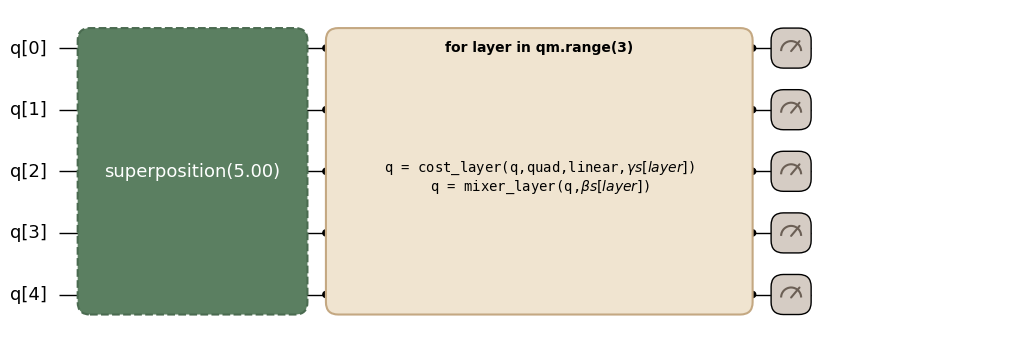

In [5]:
p = 3  # QAOA層数
qaoa_ansatz.draw(
    p=p,
    quad=spin_model.quad,
    linear=spin_model.linear,
    n=num_nodes,
)

## CUDA-Qへのトランスパイル

`CudaqTranspiler`は、他のバックエンドと同じように`transpile()`で使えます。
問題構造を決める引数は`bindings`で固定し、`gammas`/`betas`はruntimeパラメータとして残します。

In [6]:
transpiler = CudaqTranspiler()
executor = CudaqExecutor()

executable = transpiler.transpile(
    qaoa_ansatz,
    bindings={
        "p": p,
        "quad": spin_model.quad,
        "linear": spin_model.linear,
        "n": num_nodes,
    },
    parameters=["gammas", "betas"],
)

`executable.get_first_circuit()`で、QamomileのCUDA-Qバックエンドartifactである`CudaqKernelArtifact`を取り出せます。
これは生成された`@cudaq.kernel`関数を包むQamomile側のwrapperであり、CUDA-Q本体のPythonパッケージが提供する型ではありません。
artifactは、生成されたCUDA-Q量子カーネルのPythonソース文字列を確認できる形で保持し、$2p$個のQAOA角度(`gammas[0..p-1]`、`betas[0..p-1]`)が名前付きruntimeパラメータとして残っています。
`type(...)`、量子ビット数、パラメータ数で確認し、生成されたソースも見てみましょう。
このソース文字列は、QamomileがCUDA-Qに渡した内容を正確に確認したい場合に便利です。たとえば、下の`rzz`層のようなゲート分解も確認できます。

In [7]:
cudaq_artifact = executable.get_first_circuit()
assert (
    cudaq_artifact is not None
)  # transpile()はここで必ず1つの量子セグメントを生成する
# `num_qubits`と`param_count`は問題設定から一意に決まります。
# 量子ビット数はグラフのノード数と一致し、runtimeパラメータ数は層ごとに
# (gamma | beta)の組が1つずつ、合計2pになります。CUDA-Qのemitパスに
# 回帰が起きた場合にdocsテストで検知できるようassertします。
assert cudaq_artifact.num_qubits == num_nodes
assert cudaq_artifact.param_count == 2 * p
assert cudaq_artifact.execution_mode == ExecutionMode.STATIC
assert len(executable.parameter_names) == 2 * p
print(type(cudaq_artifact).__name__)
print("execution_mode :", cudaq_artifact.execution_mode.value)
print("num_qubits     :", cudaq_artifact.num_qubits)
print("param_count    :", cudaq_artifact.param_count)
print("parameter_names:", executable.parameter_names)

assert "@cudaq.kernel" in cudaq_artifact.source
assert "x.ctrl" in cudaq_artifact.source
assert "rz(" in cudaq_artifact.source
print(cudaq_artifact.source)

CudaqKernelArtifact
execution_mode : static
num_qubits     : 5
param_count    : 6
parameter_names: ['gammas[0]', 'betas[0]', 'gammas[1]', 'betas[1]', 'gammas[2]', 'betas[2]']
@cudaq.kernel
def _qamomile_kernel(thetas: list[float]):
    q = cudaq.qvector(5)
    __b0 = False
    __b1 = False
    __b2 = False
    __b3 = False
    __b4 = False
    h(q[0])
    h(q[1])
    h(q[2])
    h(q[3])
    h(q[4])
    x.ctrl(q[0], q[1])
    rz((1.0) * (thetas[0]), q[1])
    x.ctrl(q[0], q[1])
    x.ctrl(q[0], q[2])
    rz((1.0) * (thetas[0]), q[2])
    x.ctrl(q[0], q[2])
    x.ctrl(q[1], q[2])
    rz((1.0) * (thetas[0]), q[2])
    x.ctrl(q[1], q[2])
    x.ctrl(q[1], q[3])
    rz((1.0) * (thetas[0]), q[3])
    x.ctrl(q[1], q[3])
    x.ctrl(q[2], q[3])
    rz((1.0) * (thetas[0]), q[3])
    x.ctrl(q[2], q[3])
    x.ctrl(q[3], q[4])
    rz((1.0) * (thetas[0]), q[4])
    x.ctrl(q[3], q[4])
    rx((thetas[1]) * (2.0), q[0])
    rx((thetas[1]) * (2.0), q[1])
    rx((thetas[1]) * (2.0), q[2])
    rx((thetas[1

各runtimeパラメータは、実行時まで未バインドのまま残ります。
そのため、`gammas`/`betas`のバインドはQamomile側での作り直しではなく、CUDA-Q側でのパラメータ値の更新として扱われます。
Ising係数、量子ビット数、層数といった問題構造はコンパイル時に固定され、runtime入力として残るのは変分角度だけです。

## `CudaqExecutor`によるQAOAサンプリング

`executable.sample(executor, bindings=..., shots=...)`は`SampleJob`を返します。
`.result()`で得られる`SampleResult`は、`BinaryModel.decode_from_sampleresult`でスピン変数$(+1 / -1)$の`BinarySampleSet`にデコードできます。
これにより、追加の変換なしでカット辺を数えられます。
`CudaqExecutor()`はactiveなCUDA-Q target上で動作します。既定ではCUDA-QのローカルCPU simulatorです。

In [8]:
rng = np.random.default_rng(42)
init_params = rng.uniform(-np.pi / 2, np.pi / 2, 2 * p)
init_gammas = list(init_params[:p])
init_betas = list(init_params[p:])
docs_test_mode = os.environ.get("QAMOMILE_DOCS_TEST") == "1"
sample_shots = 256 if docs_test_mode else 2000
maxiter = 20 if docs_test_mode else 100

sample_result = executable.sample(
    executor,
    bindings={"gammas": init_gammas, "betas": init_betas},
    shots=sample_shots,
).result()

decoded = spin_model.decode_from_sampleresult(sample_result)
print(f"Mean energy at random init: {decoded.energy_mean():+.4f}")

Mean energy at random init: -0.5220


## QAOAパラメータの最適化

同じ`ExecutableProgram`オブジェクトを異なる`(gammas, betas)`で繰り返し呼び出すのが、QAOAの最適化ループの基本形です。
`transpiler.transpile()`を1回呼び、その後は`executable.sample()`を何度も呼び出します。
この例では、サンプリングとデコードの処理を`cost_fn()`として定義し、SciPyの`minimize`関数で最適化します。
古典Optimizerは`(gammas, betas)`を更新しながら、サンプリングされたIsingエネルギーの平均を下げていきます。
各反復では、同じ`ExecutableProgram`オブジェクトと`CudaqExecutor`を再利用します。

In [9]:
cost_history: list[float] = []


def cost_fn(params: np.ndarray) -> float:
    result = executable.sample(
        executor,
        bindings={"gammas": list(params[:p]), "betas": list(params[p:])},
        shots=sample_shots,
    ).result()
    energy = spin_model.decode_from_sampleresult(result).energy_mean()
    cost_history.append(energy)
    return energy


res = minimize(cost_fn, init_params, method="COBYLA", options={"maxiter": maxiter})

opt_gammas = list(res.x[:p])
opt_betas = list(res.x[p:])
print(f"Optimized mean energy: {res.fun:+.4f}")
print(f"Optimal gammas       : {[round(float(v), 4) for v in opt_gammas]}")
print(f"Optimal betas        : {[round(float(v), 4) for v in opt_betas]}")

Optimized mean energy: -1.2630
Optimal gammas       : [1.987, -0.8432, 0.905]
Optimal betas        : [-0.0397, -1.6194, 1.2841]


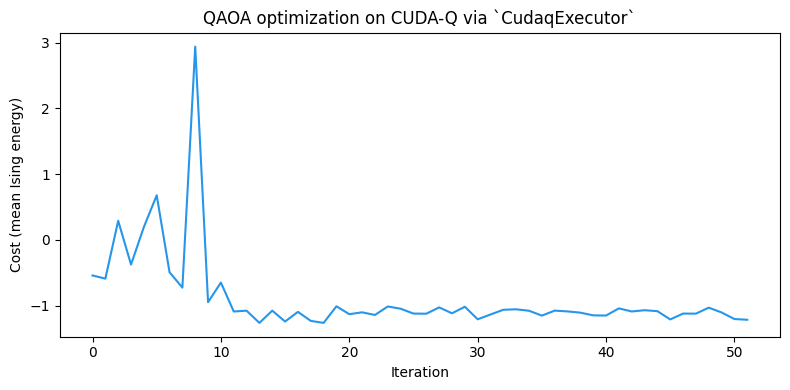

In [10]:
plt.figure(figsize=(8, 4))
plt.plot(cost_history, color="#2696EB")
plt.xlabel("Iteration")
plt.ylabel("Cost (mean Ising energy)")
plt.title("QAOA optimization on CUDA-Q via `CudaqExecutor`")
plt.tight_layout()
plt.show()

サンプリングには乱数が入るため、最適化の軌跡や最終的な標本平均エネルギーは実行ごとに少し変わる場合があります。
CUDA-Q targetを変えた場合も、使用するsimulator実装の違いで同様の揺らぎが出ることがあります。
それでも、この5ノードグラフ上の$H_C$の基底状態エネルギー付近までは収束するはずです。
ここで得た最適パラメータ(`opt_gammas`、`opt_betas`)を、以降の例でも使います。

## `cudaq.observe`による期待値

`STATIC`なCUDA-Q artifactでは、`CudaqExecutor.estimate(circuit, hamiltonian, params=...)`が内部で`cudaq.observe()`を呼び出します。
上の測定付きQAOAアンザッツも、状態準備回路としてそのまま使えます。`STATIC` artifactでは、Qamomileは終端測定を生成されるCUDA-Q量子カーネルに書き込みません。
サンプリング時には最後の測定を別途扱うため、同じartifactを`cudaq.observe()`にも渡せます。
QAOAの最適化でも、同じ回路を保ったまま`ExecutableProgram.sample()`とデコードの組み合わせを`executor.estimate(circuit, hamiltonian, params=...)`に置き換えられます。

まずQamomileの`Hamiltonian`として$H_C = \sum_{(i,j) \in E} Z_i Z_j$を組み立てます。
その後、`transpile()`が出力したCUDA-Q artifactに対して`executor.estimate`を呼び出します。

In [11]:
cost_hamiltonian = qm_o.Hamiltonian()
for (i, j), Jij in spin_model.quad.items():
    cost_hamiltonian.add_term(
        (qm_o.PauliOperator(qm_o.Pauli.Z, i), qm_o.PauliOperator(qm_o.Pauli.Z, j)),
        Jij,
    )
for i, hi in spin_model.linear.items():
    cost_hamiltonian.add_term((qm_o.PauliOperator(qm_o.Pauli.Z, i),), hi)

unbound_circuit = executable.get_first_circuit()
assert unbound_circuit is not None
assert unbound_circuit.execution_mode == ExecutionMode.STATIC
print(f"artifact type       : {type(unbound_circuit).__name__}")
print(f"artifact param_count: {unbound_circuit.param_count}")

# CUDA-Qはruntimeパラメータを「artifactに登録された順序のフラットなリスト」
# として要求します。登録順は回路を出力したときの初出順で決まるため、QAOAでは
# gammas[0], betas[0], gammas[1], betas[1], ...と層ごとに交互の順になります。
# 「全gammasのあとに全betas」という順序ではない点に注意してください。
# 順序を推測しなくて済むよう、`ExecutableProgram`から登録順を読み取り、
# 名前で値を引いてフラットなリストに整えます。
named_values = {f"gammas[{i}]": opt_gammas[i] for i in range(p)}
named_values.update({f"betas[{i}]": opt_betas[i] for i in range(p)})
flat_params = [named_values[name] for name in executable.parameter_names]
# runtimeパラメータは2p個のQAOA角度のみ。CudaqTranspilerの
# パラメータ登録方法が将来変わった場合に検知できるようassertします。
assert len(executable.parameter_names) == 2 * p
assert len(flat_params) == 2 * p
print(f"artifact parameter order: {executable.parameter_names}")

energy_via_estimate = executor.estimate(
    unbound_circuit, cost_hamiltonian, params=flat_params
)
print(f"executor.estimate: {energy_via_estimate:+.10f}")
assert np.isfinite(energy_via_estimate)

artifact type       : CudaqKernelArtifact
artifact param_count: 6
artifact parameter order: ['gammas[0]', 'betas[0]', 'gammas[1]', 'betas[1]', 'gammas[2]', 'betas[2]']
executor.estimate: -1.1169335401


`ExecutableProgram.run(...)`で、期待値を返す量子カーネルを直接実行することもできます。
次の量子カーネルでは、ObservableをQamomileのruntime引数として受け取り、測定ビットではなく`qmc.expval(...)`を返します。
この1段高い抽象度の経路でも`CudaqExecutor.estimate`に到達しますが、ObservableとパラメータのbindingsはQamomileの`ExecutableProgram`が管理します。

In [12]:
@qmc.qkernel
def qaoa_expval(
    p: qmc.UInt,
    quad: qmc.Dict[qmc.Tuple[qmc.UInt, qmc.UInt], qmc.Float],
    linear: qmc.Dict[qmc.UInt, qmc.Float],
    n: qmc.UInt,
    gammas: qmc.Vector[qmc.Float],
    betas: qmc.Vector[qmc.Float],
    obs: qmc.Observable,
) -> qmc.Float:
    q = superposition(n)
    for layer in qmc.range(p):
        q = cost_layer(quad, linear, q, gammas[layer])
        q = mixer_layer(q, betas[layer])
    return qmc.expval(q, obs)


expval_executable = transpiler.transpile(
    qaoa_expval,
    bindings={
        "p": p,
        "quad": spin_model.quad,
        "linear": spin_model.linear,
        "n": num_nodes,
        "obs": cost_hamiltonian,
    },
    parameters=["gammas", "betas"],
)
energy_from_run = expval_executable.run(
    executor,
    bindings={"gammas": opt_gammas, "betas": opt_betas},
).result()

print(f"ExecutableProgram.run: {energy_from_run:+.10f}")
assert np.isclose(energy_from_run, energy_via_estimate, atol=1e-10)

ExecutableProgram.run: -1.1169335401


両方の経路は数値精度の範囲で一致します。
同じQAOA状態を、同じIsingコストハミルトニアンに対して評価しているためです。
また、最適化後パラメータでのこのノイズなし期待値は、先ほど出力した標本平均エネルギーともショットノイズの範囲で一致するはずです。

## CUDA-Q targetの選択

`CudaqExecutor()`は現在のCUDA-Q targetを使い、`CudaqExecutor(target=...)`または`CudaqTranspiler.executor(target=...)`はtargetを明示的に選択します。
差し替えたexecutorは、上で使った`executor`の位置にそのまま当てはめられます。
CUDA-Q targetを変えても、量子カーネルをトランスパイルし直す必要はありません。
`ExecutableProgram`が出力済みのCUDA-Q artifactを持ち、executorがruntime targetの選択を持つ、という役割分担になっているためです。
選択できるsimulator targetの一覧は、CUDA-Q公式ドキュメントの[Circuit Simulation Backends](https://nvidia.github.io/cuda-quantum/latest/using/backends/simulators.html)で確認できます。

ローカルで試せる具体例として、まず既定targetで**同じ**最適化済みQAOA`ExecutableProgram`をサンプリングします。
その後で、小さなdepolarization noise modelを有効にしたCUDA-Qの`density-matrix-cpu`targetへ切り替えます。

density-matrix simulatorは、CPU上でノイズありシミュレーションを行いたい場合に便利です。
CUDA-Qには、1量子ビット操作向けの`Depolarization1`と、2量子ビット操作向けの`Depolarization2`があります。
QamomileのCUDA-Q emitterは各`rzz`を`x.ctrl`/`rz`/`x.ctrl`へ分解するため、下のnoise modelでは回転ゲートに1量子ビットdepolarizationを掛け、制御付き`x`ゲート(`num_controls=1`)に2量子ビットdepolarizationを掛けます。

CUDA-Qのnoise model APIでは、制御付き`x`はoperator`"x"`に`num_controls=1`を付けて登録します。`"x.ctrl"`という別のoperator名ではありません。
CUDA-Qではactiveなtargetとnoise modelがどちらもglobalに保持され、`cudaq.set_target(...)`を呼ぶと現在のnoise modelが消えます。
ノイズあり実行では、先にtargetを設定し、その後でnoise modelを設定し、呼び出し中に`target=...`を再適用しないExecutorでサンプリングします。

GPU対応インストールでは、GPU backendを持つCUDA-Q targetやノイズ対応simulatorでも同じやり方が使えます。

In [13]:
default_result = executable.sample(
    executor,
    bindings={"gammas": opt_gammas, "betas": opt_betas},
    shots=sample_shots,
).result()
noise_probability = 0.02
noise_model = cudaq.NoiseModel()
for gate_name in ("h", "rx", "rz"):
    noise_model.add_all_qubit_channel(
        gate_name, cudaq.Depolarization1(noise_probability)
    )
noise_model.add_all_qubit_channel(
    "x",
    cudaq.Depolarization2(noise_probability),
    num_controls=1,
)

try:
    cudaq.set_target("density-matrix-cpu")
    cudaq.set_noise(noise_model)
    noisy_density_result = executable.sample(
        executor,
        bindings={"gammas": opt_gammas, "betas": opt_betas},
        shots=sample_shots,
    ).result()
finally:
    cudaq.unset_noise()
    cudaq.reset_target()

default_decoded = spin_model.decode_from_sampleresult(default_result)
noisy_density_decoded = spin_model.decode_from_sampleresult(noisy_density_result)
default_energy = default_decoded.energy_mean()
noisy_density_energy = noisy_density_decoded.energy_mean()
print(f"default target mean energy           : {default_energy:+.4f}")
print(f"density-matrix-cpu noisy mean energy: {noisy_density_energy:+.4f}")

default target mean energy           : -1.0650
density-matrix-cpu noisy mean energy: -0.5090


どちらのtarget実行もサンプリングなので、サンプルされたエネルギー分布を直接比較できます。
各subplotの縦線は、標本平均エネルギーを表します。

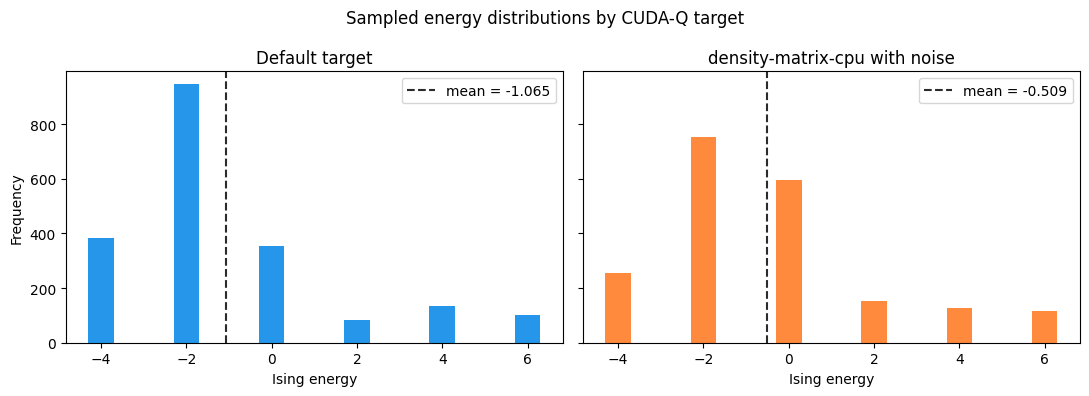

In [14]:


def energy_distribution(decoded_samples):
    counts: Counter[float] = Counter()
    for energy, occ in zip(decoded_samples.energy, decoded_samples.num_occurrences):
        counts[energy] += occ
    energies = sorted(counts.keys())
    return energies, [counts[energy] for energy in energies]


fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, decoded_samples, mean_energy, title, color in [
    (axes[0], default_decoded, default_energy, "Default target", "#2696EB"),
    (
        axes[1],
        noisy_density_decoded,
        noisy_density_energy,
        "density-matrix-cpu with noise",
        "#FF8A3D",
    ),
]:
    energies, counts = energy_distribution(decoded_samples)
    ax.bar(energies, counts, width=0.6, color=color)
    ax.axvline(
        mean_energy,
        color="#2B2B2B",
        linestyle="--",
        linewidth=1.5,
        label=f"mean = {mean_energy:+.3f}",
    )
    ax.set_xticks(energies)
    ax.set_title(title)
    ax.set_xlabel("Ising energy")
    ax.legend()

axes[0].set_ylabel("Frequency")
fig.suptitle("Sampled energy distributions by CUDA-Q target")
fig.tight_layout()
plt.show()

## runtime制御フロー: `STATIC` artifactと`RUNNABLE` artifact

上のQAOAアンザッツを含む多くの変分回路は、`ExecutionMode.STATIC`にコンパイルされます。
`STATIC` artifactでは、生成されたCUDA-Qソースに明示的な終端測定は入りません。そのため、CUDA-Qの`sample` APIと`observe` APIに対応しています。

Qamomile量子カーネルが`if bit:`や`while bit:`のようなruntime測定依存の制御フローを含む場合、CUDA-Qバックエンドは代わりに`ExecutionMode.RUNNABLE` artifactを出力します。
`RUNNABLE` artifactでは、生成されたソースに明示的な`mz(...)`測定が入り、`cudaq.run()`で実行されます。
次の小さなfeed-forward回路で、この経路を確認します。

In [15]:
@qmc.qkernel
def measurement_feed_forward() -> qmc.Bit:
    q0 = qmc.qubit("q0")
    q1 = qmc.qubit("q1")
    q0 = qmc.x(q0)
    bit = qmc.measure(q0)
    if bit:
        q1 = qmc.x(q1)
    return qmc.measure(q1)


runnable_executable = transpiler.transpile(measurement_feed_forward)
runnable_circuit = runnable_executable.get_first_circuit()
assert runnable_circuit is not None
assert runnable_circuit.execution_mode == ExecutionMode.RUNNABLE
assert "mz(" in runnable_circuit.source
assert "if " in runnable_circuit.source

print("execution_mode:", runnable_circuit.execution_mode.value)
print(runnable_circuit.source)

execution_mode: runnable
@cudaq.kernel
def _qamomile_kernel() -> list[bool]:
    q = cudaq.qvector(2)
    __b0 = False
    __b1 = False
    x(q[0])
    __b0 = mz(q[0])
    if __b0:
        x(q[1])
    __b1 = mz(q[1])
    return [__b0, __b1]



`RUNNABLE` artifactでも`ExecutableProgram.sample(...)`はそのまま使えます。ただし、Executorは`cudaq.sample()`ではなく`cudaq.run()`へdispatchします。
上の例は決定的です。最初の測定は常に`1`になるため、分岐で`q1`が反転し、戻り値のbitも常に`1`になります。

In [16]:
runnable_shots = 128
runnable_sample = runnable_executable.sample(executor, shots=runnable_shots).result()
print(runnable_sample.results)
assert sum(count for _, count in runnable_sample.results) == runnable_shots
assert all(value == 1 for value, _ in runnable_sample.results)

[(1, 128)]


一方、`RUNNABLE` artifactはCUDA-Qの`observe` APIには対応していません。
Qamomileでは、`RUNNABLE` artifactに対して`estimate()`を呼ぶと`TypeError`としてこの違いを通知します。

In [17]:
try:
    executor.estimate(runnable_circuit, qm_o.Z(0))
except TypeError as exc:
    print(type(exc).__name__, exc)
else:
    raise AssertionError("RUNNABLE CUDA-Q circuits must reject observe()")

TypeError cudaq.observe() is not supported for runtime control flow circuits. Use sample() or run() instead.


## まとめ

- `CudaqTranspiler().transpile(kernel, bindings=..., parameters=[...])`は、カーネルをPythonソースを確認できるCUDA-Q artifactに変換します。
- `CudaqExecutor`は、QAOA形式のサンプリングを行う`ExecutableProgram.sample()`と、CUDA-Qの`observe` APIによるノイズなし期待値計算を行う`executor.estimate(...)`の両方をサポートします。
- QAOA形式の`STATIC` artifactは、量子カーネルを再トランスパイルせずに、多くのruntimeパラメータベクトルで再利用できます。
- runtime測定依存の制御フローは`ExecutionMode.RUNNABLE`として出力され、`cudaq.run()`経由で実行されます。
- CUDA-Q targetは`CudaqExecutor(target=...)`または`CudaqTranspiler.executor(target=...)`で選択できます。`ExecutableProgram`をトランスパイルし直す必要はありません。

### See also

- [QURI Partsサポート](quri_parts_support.ipynb)では、同じMaxCut QAOAの流れをQURI Partsバックエンドで扱います。